### PART 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. Load the raw OWID dataset

In [3]:
# In Colab, upload owid-co2-data.csv first (left sidebar -> Files -> upload),
# or mount Google Drive and point the path there.
df_raw = pd.read_csv("/content/owid-co2-data.csv")

print(df_raw.shape)
df_raw.head()

(50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

### 1b. Verify column types

In [5]:
print(df_raw.dtypes[["country", "year", "iso_code", "co2", "population",
                      "primary_energy_consumption", "energy_per_capita"]])

assert pd.api.types.is_integer_dtype(df_raw["year"]) or pd.api.types.is_float_dtype(df_raw["year"]), \
    "year is not numeric"
assert pd.api.types.is_numeric_dtype(df_raw["co2"]), "co2 is not numeric"
assert pd.api.types.is_numeric_dtype(df_raw["population"]), "population is not numeric"
assert pd.api.types.is_object_dtype(df_raw["country"]) or pd.api.types.is_string_dtype(df_raw["country"]), \
    "country is not a string column"
print("type checks passed")

country                        object
year                            int64
iso_code                       object
co2                           float64
population                    float64
primary_energy_consumption    float64
energy_per_capita             float64
dtype: object
type checks passed


---
## 2. Defining the country panel

17 countries (8 South Asia + 8 Southeast Asia + Mongolia), 1990-2024.

In [6]:
SOUTH_ASIA = ["Bangladesh", "Pakistan", "Nepal", "Sri Lanka",
              "India", "Bhutan", "Afghanistan", "Maldives"]

SOUTHEAST_ASIA = ["Vietnam", "Myanmar", "Cambodia", "Laos",
                  "Philippines", "Indonesia", "Thailand", "Malaysia"]

OTHER_ASIA = ["Mongolia"]

PANEL_COUNTRIES = SOUTH_ASIA + SOUTHEAST_ASIA + OTHER_ASIA
print(f"{len(PANEL_COUNTRIES)} countries in the panel")

YEAR_START, YEAR_END = 1990, 2024

missing_countries = sorted(set(PANEL_COUNTRIES) - set(df_raw["country"].unique()))
print("Countries missing from OWID data:", missing_countries)

17 countries in the panel
Countries missing from OWID data: []


---
## 3. Drop aggregate / regional rows

droping anything with a missing `iso_code`

In [7]:
n_before = len(df_raw)
df = df_raw[df_raw["iso_code"].notna()].copy()
n_after = len(df)

print(f"dropped {n_before - n_after:,} aggregate/regional rows ({n_before:,} -> {n_after:,})")

dropped 7,931 aggregate/regional rows (50,411 -> 42,480)


---
## 4. Filter to the 17 panel countries and the 1990-2024 year range

In [8]:
df = df[df["country"].isin(PANEL_COUNTRIES)]
df = df[df["year"].between(YEAR_START, YEAR_END)]

df = df.reset_index(drop=True)
print(df.shape)
df.head()

(595, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1990,AFG,12045664.0,1.306598e+10,0.046,0.004,2.024,-0.741,-26.784,...,NaN,0.090,0.0,0.0,0.001,0.0,13.519,3.123,NaN,NaN
1,Afghanistan,1991,AFG,12238879.0,1.204736e+10,0.046,0.004,1.914,-0.110,-5.435,...,NaN,0.088,0.0,0.0,0.001,0.0,13.711,3.038,NaN,NaN
2,Afghanistan,1992,AFG,13278983.0,1.267754e+10,0.046,0.003,1.482,-0.432,-22.580,...,NaN,0.087,0.0,0.0,0.001,0.0,11.543,2.606,NaN,NaN
3,Afghanistan,1993,AFG,14943175.0,9.834582e+09,0.047,0.003,1.487,0.005,0.330,...,NaN,0.085,0.0,0.0,0.001,0.0,10.454,2.664,NaN,NaN
4,Afghanistan,1994,AFG,16250800.0,7.919856e+09,0.047,0.003,1.454,-0.033,-2.227,...,NaN,0.084,0.0,0.0,0.001,0.0,10.980,2.697,NaN,NaN


---
## 5. Build the rectangular country-year grid

17 countries x 35 years (1990-2024) should give us 595 rows with no gaps.

In [9]:
expected_rows = len(PANEL_COUNTRIES) * (YEAR_END - YEAR_START + 1)
print(f"expected rows: {expected_rows}, actual rows: {len(df)}")

full_grid = pd.MultiIndex.from_product(
    [PANEL_COUNTRIES, range(YEAR_START, YEAR_END + 1)], names=["country", "year"]
).to_frame(index=False)

merged = full_grid.merge(df[["country", "year"]], on=["country", "year"], how="left", indicator=True)
gaps = merged[merged["_merge"] == "left_only"]

print(f"missing (country, year) rows: {len(gaps)}")
gaps

expected rows: 595, actual rows: 595
missing (country, year) rows: 0


,country,year,_merge


In [10]:
co2_gaps = df[df['co2'].isna()]
print(f"rows where co2 is missing: {len(co2_gaps)}")
co2_gaps

rows where co2 is missing: 0


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share


---
## 6. Check for duplicate country-year rows

In [11]:
dupe_count = df.duplicated(subset=["country", "year"]).sum()
print(f"duplicate (country, year) rows: {dupe_count}")

if dupe_count > 0:
    display_cols = ["country", "year", "co2", "population"]
    print(df[df.duplicated(subset=["country", "year"], keep=False)][display_cols])

duplicate (country, year) rows: 0


### 6b. Check for inconsistent labels

Making sure each country maps to exactly one `iso_code` and that country names don't
have hidden whitespace/case variants

In [12]:
# Each country should map to exactly one iso_code
iso_per_country = df.groupby("country")["iso_code"].nunique()
inconsistent = iso_per_country[iso_per_country > 1]
print(f"countries with more than one iso_code: {len(inconsistent)}")
print(inconsistent)

# Check for hidden whitespace / case issues in country names
raw_names = df["country"].unique()
stripped_lower = pd.Series(raw_names).str.strip().str.lower()
label_issues = pd.Series(raw_names)[stripped_lower.duplicated(keep=False)]
print(f"\npossible name variants: {len(label_issues)}")
print(label_issues.tolist())

countries with more than one iso_code: 0
Series([], Name: iso_code, dtype: int64)

possible name variants: 0
[]


---
## 7. Check missing values across all columns



share_global_other_co2                 595
cumulative_other_co2                   595
share_global_cumulative_other_co2      595
other_industry_co2                     595
other_co2_per_capita                   595
gas_co2_per_capita                     249
gas_co2                                249
cumulative_gas_co2                     249
share_global_gas_co2                   249
share_global_cumulative_gas_co2        249
consumption_co2_per_gdp                166
trade_co2                              153
consumption_co2_per_capita             153
consumption_co2                        153
trade_co2_share                        153
gdp                                    100
co2_including_luc_per_gdp              100
energy_per_gdp                         100
co2_per_gdp                            100
coal_co2_per_capita                     53
share_global_cumulative_coal_co2        53
share_global_coal_co2                   53
coal_co2                                53
cumulative_

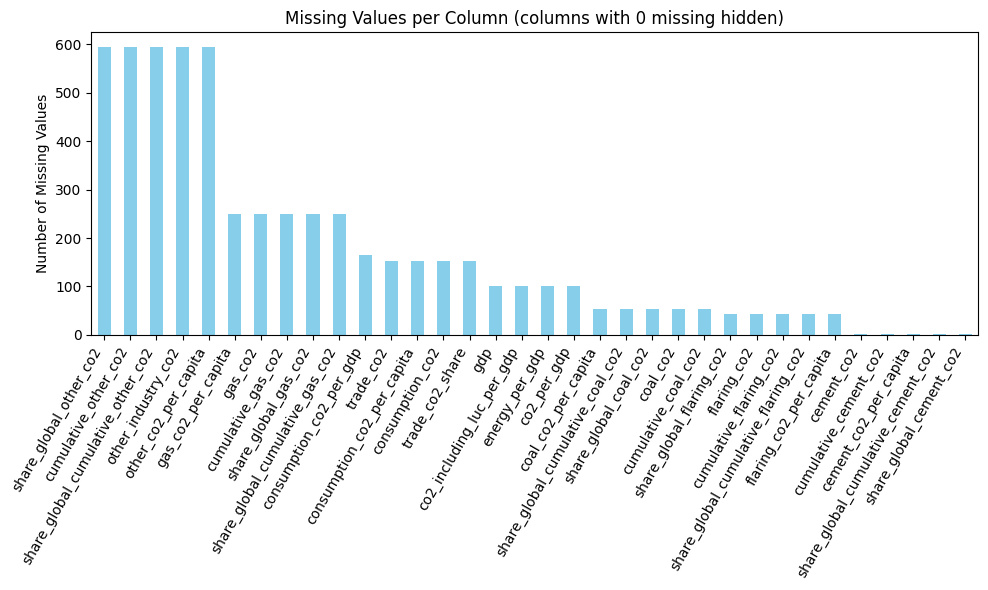

In [13]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Visualize missing values
plt.figure(figsize=(10, 6))
missing.plot(kind="bar", color="skyblue")
plt.title("Missing Values per Column (columns with 0 missing hidden)")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

---
## 8. Check for non-positive CO2 values

`co2` needs to be strictly positive later for the log transform

In [14]:
non_positive = df[df["co2"] <= 0]
print(f"non-positive co2 rows: {len(non_positive)}")
non_positive

non-positive co2 rows: 0


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share


### 8b. Range checks on other key columns



In [15]:
range_checks = {
    "population": (df["population"] > 0),
    "primary_energy_consumption": (df["primary_energy_consumption"] >= 0),
    "energy_per_capita": (df["energy_per_capita"] >= 0),
}

for col, valid_mask in range_checks.items():
    valid_mask = valid_mask | df[col].isna()
    n_bad = (~valid_mask).sum()
    print(f"{col}: {n_bad} out-of-range rows")
    if n_bad > 0:
        print(df[~valid_mask][["country", "year", col]])

population: 0 out-of-range rows
primary_energy_consumption: 0 out-of-range rows
energy_per_capita: 0 out-of-range rows


---
## 9. Check for outliers per country

We flag outliers within each country's own CO2 series using the IQR rule, rather than
across the whole panel — Bangladesh's low emissions shouldn't be flagged relative to
India's much larger scale.

In [16]:
def flag_outliers_iqr(group, col="co2", k=1.5):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (group[col] < lower) | (group[col] > upper)

df["co2_outlier"] = df.groupby("country", group_keys=False).apply(
    lambda g: flag_outliers_iqr(g)
)

print(f"flagged {df['co2_outlier'].sum()} outlier rows (per-country IQR rule)")
df[df["co2_outlier"]][["country", "year", "co2"]]

flagged 7 outlier rows (per-country IQR rule)


/tmp/ipykernel_1007/2684514543.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["co2_outlier"] = df.groupby("country", group_keys=False).apply(


,country,year,co2
135,Cambodia,2020,20.991
136,Cambodia,2021,20.775
137,Cambodia,2022,20.865
138,Cambodia,2023,21.412
139,Cambodia,2024,21.883
418,Nepal,2023,18.348
419,Nepal,2024,18.776


---
## 10. Plot the target (CO2) distribution

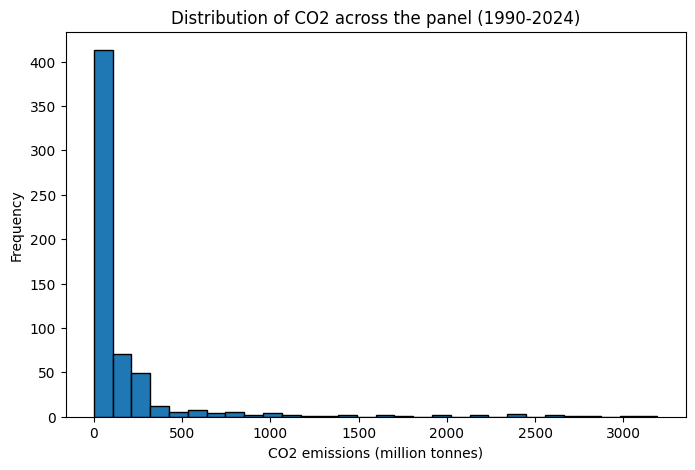

Mean CO2: 170.3828168067227
Median CO2: 21.88


In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["co2"], bins=30, edgecolor="black")
plt.xlabel("CO2 emissions (million tonnes)")
plt.ylabel("Frequency")
plt.title("Distribution of CO2 across the panel (1990-2024)")
plt.show()

print("Mean CO2:", df["co2"].mean())
print("Median CO2:", df["co2"].median())

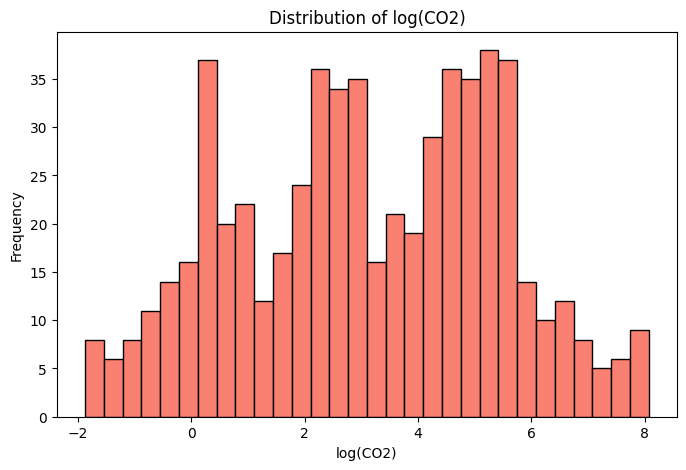

In [18]:
# CO2 is heavily right-skewed (India dwarfs the smaller economies) — log scale makes
# the shape easier to read
plt.figure(figsize=(8, 5))
plt.hist(np.log(df["co2"]), bins=30, edgecolor="black", color="salmon")
plt.xlabel("log(CO2)")
plt.ylabel("Frequency")
plt.title("Distribution of log(CO2)")
plt.show()

---
## 11. Exploratory relationship: population vs CO2

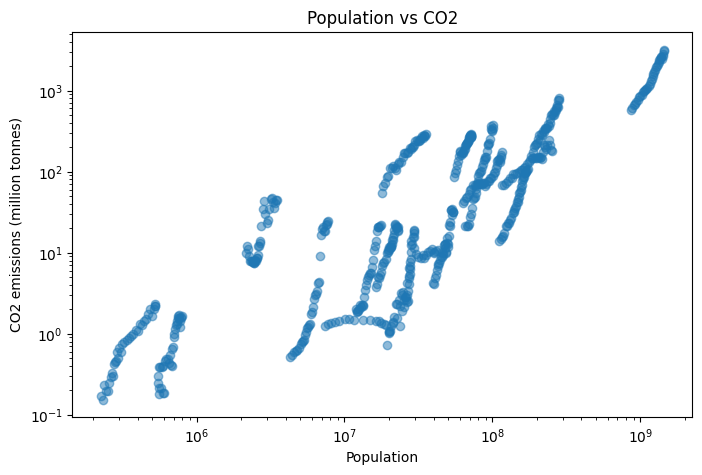

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df["population"], df["co2"], alpha=0.5)
plt.xlabel("Population")
plt.ylabel("CO2 emissions (million tonnes)")
plt.title("Population vs CO2")
plt.xscale("log")
plt.yscale("log")
plt.show()

### PART 2

### 12 Handle Missing Data

In [20]:
# Drop columns with >25% missing data and impute the rest with median
missing_pct = df.isna().mean() * 100
cols_to_drop = missing_pct[missing_pct > 25.0].index
df_filtered = df.drop(columns=cols_to_drop).copy()

numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
medians = df_filtered[numeric_cols].median()
df_filtered[numeric_cols] = df_filtered[numeric_cols].fillna(medians)

print(f"Dropped {len(cols_to_drop)} columns with > 25% missing data.")
print(f"Remaining columns ({len(df_filtered.columns)}):")
print(df_filtered.columns.tolist())

Dropped 15 columns with > 25% missing data.
Remaining columns (65):
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita', 'oil_co2', 'oil_co2_per_capita', 'primary_energy_consumption', 'share_global_cement_co2

### 13 Proof of Data Leakage & Feature Selection



In [21]:
# Mathematically recreate 'co2_growth_abs' from our target 'co2'
proof_df = df_filtered[['country', 'year', 'co2', 'co2_growth_abs']].copy()
proof_df['calculated_growth'] = proof_df.groupby('country')['co2'].diff()

print(proof_df[proof_df['country'] == 'Bangladesh'].head())

features_to_keep = [
    'country', 'year', 'iso_code', 'co2', 'population', 'gdp',
    'primary_energy_consumption', 'energy_per_capita',
    'co2_per_capita', 'methane', 'nitrous_oxide'
]

df_clean = df_filtered[features_to_keep].copy()
df_clean = df_clean.sort_values(by=['country', 'year']).reset_index(drop=True)

print(f"\nFinal selected features ({len(features_to_keep)}):")
print(features_to_keep)


       country  year     co2  co2_growth_abs  calculated_growth
35  Bangladesh  1990  14.082           0.699                NaN
36  Bangladesh  1991  14.753           0.671              0.671
37  Bangladesh  1992  15.391           0.638              0.638
38  Bangladesh  1993  16.074           0.683              0.683
39  Bangladesh  1994  17.553           1.479              1.479

Final selected features (11):
['country', 'year', 'iso_code', 'co2', 'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'co2_per_capita', 'methane', 'nitrous_oxide']


### 14 Feature Engineering

In [22]:
import numpy as np

# Log transform the target (adding 1e-6 to avoid log(0))
df_clean['log_co2'] = np.log(df_clean['co2'] + 1e-6)

# Create 1, 2, and 3-year lags for historical context
features_to_lag = ['co2', 'population', 'gdp', 'primary_energy_consumption']
for feature in features_to_lag:
    for lag in [1, 2, 3]:
        df_clean[f'{feature}_lag_{lag}'] = df_clean.groupby('country')[feature].shift(lag)


df_engineered = df_clean.dropna().reset_index(drop=True)

print(f"Total Features: {len(df_engineered.columns)}")
print("Final Engineered Features:")
print(df_engineered.columns.tolist())


Total Features: 24
Final Engineered Features:
['country', 'year', 'iso_code', 'co2', 'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'co2_per_capita', 'methane', 'nitrous_oxide', 'log_co2', 'co2_lag_1', 'co2_lag_2', 'co2_lag_3', 'population_lag_1', 'population_lag_2', 'population_lag_3', 'gdp_lag_1', 'gdp_lag_2', 'gdp_lag_3', 'primary_energy_consumption_lag_1', 'primary_energy_consumption_lag_2', 'primary_energy_consumption_lag_3']


## 15 Dataset Splitting

In [23]:
# Future Target (3 years ahead)
df_engineered['target_3yr_ahead'] = df_engineered.groupby('country')['log_co2'].shift(-3)

# Drop the last 3 years for each country (no target available)
df_model = df_engineered.dropna().reset_index(drop=True)

# 2. Chronological Split
train_df = df_model[df_model['year'] <= 2015].copy()
val_df = df_model[(df_model['year'] > 2015) & (df_model['year'] <= 2019)].copy()
test_df = df_model[df_model['year'] > 2019].copy()

print(f"Training data size: {len(train_df)} rows (Years: {train_df['year'].min()} to {train_df['year'].max()})")
print(f"Validation data size: {len(val_df)} rows (Years: {val_df['year'].min()} to {val_df['year'].max()})")
print(f"Testing data size: {len(test_df)} rows (Years: {test_df['year'].min()} to {test_df['year'].max()})")

Training data size: 391 rows (Years: 1993 to 2015)
Validation data size: 68 rows (Years: 2016 to 2019)
Testing data size: 34 rows (Years: 2020 to 2021)


## 16 Encoding and Scaling

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Drop 'year', 'iso_code', and our targets from the features
cols_to_drop = ['year', 'iso_code', 'target_3yr_ahead']

# 1. One-Hot Encode the 'country' column
X_train = pd.get_dummies(train_df.drop(columns=cols_to_drop), columns=['country'], drop_first=True)
X_val = pd.get_dummies(val_df.drop(columns=cols_to_drop), columns=['country'], drop_first=True)
X_test = pd.get_dummies(test_df.drop(columns=cols_to_drop), columns=['country'], drop_first=True)


# Separate the Targets
y_train = train_df['target_3yr_ahead']
y_val = val_df['target_3yr_ahead']
y_test = test_df['target_3yr_ahead']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets using the training scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"{X_train_scaled.shape[1]} fully prepared mathematical features ready for the model.")

37 fully prepared mathematical features ready for the model.


## 17 Simple Baseline


In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mean_guess = y_train.mean()

val_predictions = np.full(shape=len(y_val), fill_value=mean_guess)

actual_co2 = np.exp(y_val)
predicted_co2 = np.exp(val_predictions)

mae = mean_absolute_error(actual_co2, predicted_co2)
rmse = np.sqrt(mean_squared_error(actual_co2, predicted_co2))
r2 = r2_score(actual_co2, predicted_co2)

print(f"SIMPLE MEAN BASELINE RESULTS")
print(f"Validation MAE:  {mae:.2f} Mt")
print(f"Validation RMSE: {rmse:.2f} Mt")
print(f"Validation R-Squared: {r2:.2f}")

SIMPLE MEAN BASELINE RESULTS
Validation MAE:  268.03 Mt
Validation RMSE: 666.36 Mt
Validation R-Squared: -0.18


In [26]:
baseline_rmse = rmse
baseline_mae = mae
baseline_r2 = r2

### PART 3

1.Import Library


In [47]:
import pandas as pd
import numpy as np

import time

from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from xgboost import XGBRegressor


from sklearn.metrics import mean_squared_error

from sklearn.model_selection import ParameterGrid

2. Random Seed

In [48]:
RANDOM_STATE = 42

3.KNN Model


In [49]:
knn = KNeighborsRegressor()

In [50]:
knn_params = {

    "n_neighbors":[3,5,7,10],

    "weights":[
        "uniform",
        "distance"
    ]

}

In [51]:
best_knn = None

best_knn_rmse = 999999


for params in ParameterGrid(knn_params):


    model = KNeighborsRegressor(
        **params
    )


    start = time.time()


    model.fit(
        X_train_scaled,
        y_train
    )


    train_time = time.time()-start


    pred = model.predict(
        X_val_scaled
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )


    print(
        params,
        "RMSE:",
        rmse
    )


    if rmse < best_knn_rmse:

        best_knn_rmse = rmse

        best_knn = model



print("Best KNN RMSE:",best_knn_rmse)

{'n_neighbors': 3, 'weights': 'uniform'} RMSE: 0.23102904398969323
{'n_neighbors': 3, 'weights': 'distance'} RMSE: 0.21922454075825407
{'n_neighbors': 5, 'weights': 'uniform'} RMSE: 0.32779430167584817
{'n_neighbors': 5, 'weights': 'distance'} RMSE: 0.29679825264645704
{'n_neighbors': 7, 'weights': 'uniform'} RMSE: 0.424008448923711
{'n_neighbors': 7, 'weights': 'distance'} RMSE: 0.3748242319531085
{'n_neighbors': 10, 'weights': 'uniform'} RMSE: 0.558876819905079
{'n_neighbors': 10, 'weights': 'distance'} RMSE: 0.4756895714265284
Best KNN RMSE: 0.21922454075825407


4.Random Forest

In [52]:
rf_params = {


    "n_estimators":[100,200],

    "max_depth":[5,10,None]


}

In [53]:
best_rf = None

best_rf_rmse = 999999



for params in ParameterGrid(rf_params):


    model = RandomForestRegressor(

        random_state=RANDOM_STATE,

        **params

    )


    start=time.time()


    model.fit(
        X_train_scaled,
        y_train
    )


    train_time=time.time()-start



    pred=model.predict(
        X_val_scaled
    )


    rmse=np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )


    print(
        params,
        "RMSE:",
        rmse
    )


    if rmse < best_rf_rmse:

        best_rf_rmse=rmse

        best_rf=model



print(
    "Best RF RMSE:",
    best_rf_rmse
)

{'max_depth': 5, 'n_estimators': 100} RMSE: 0.22769746413035405
{'max_depth': 5, 'n_estimators': 200} RMSE: 0.22688788602675236
{'max_depth': 10, 'n_estimators': 100} RMSE: 0.22835727946158998
{'max_depth': 10, 'n_estimators': 200} RMSE: 0.22638455647043457
{'max_depth': None, 'n_estimators': 100} RMSE: 0.23006562809429515
{'max_depth': None, 'n_estimators': 200} RMSE: 0.22978373536514482
Best RF RMSE: 0.22638455647043457


5: XGBoost

In [54]:
xgb_params={


    "n_estimators":[100,200],

    "max_depth":[3,5],

    "learning_rate":[0.01,0.1]


}

In [55]:
best_xgb=None

best_xgb_rmse=999999



for params in ParameterGrid(xgb_params):


    model=XGBRegressor(

        random_state=RANDOM_STATE,

        **params

    )


    start=time.time()


    model.fit(
        X_train_scaled,
        y_train
    )


    train_time=time.time()-start



    pred=model.predict(
        X_val_scaled
    )


    rmse=np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )


    print(
        params,
        "RMSE:",
        rmse
    )


    if rmse < best_xgb_rmse:

        best_xgb_rmse=rmse

        best_xgb=model



print(
    "Best XGB RMSE:",
    best_xgb_rmse
)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100} RMSE: 0.9064122173748548
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200} RMSE: 0.45908575844870764
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100} RMSE: 0.9027813083302823
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200} RMSE: 0.44609931768996436
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} RMSE: 0.2477855459499869
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} RMSE: 0.2513418863500523
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100} RMSE: 0.2274183535585266
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200} RMSE: 0.22661413459440213
Best XGB RMSE: 0.22661413459440213


6: SVM

In [56]:
svm_params={


    "C":[0.1,1,10],

    "kernel":[
        "linear",
        "rbf"
    ]

}

In [57]:
best_svm=None

best_svm_rmse=999999



for params in ParameterGrid(svm_params):


    model=SVR(
        **params
    )


    start=time.time()


    model.fit(
        X_train_scaled,
        y_train
    )


    pred=model.predict(
        X_val_scaled
    )


    rmse=np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )


    print(
        params,
        "RMSE:",
        rmse
    )



    if rmse < best_svm_rmse:

        best_svm_rmse=rmse

        best_svm=model



print(
    "Best SVM RMSE:",
    best_svm_rmse
)

{'C': 0.1, 'kernel': 'linear'} RMSE: 0.2216434217568744
{'C': 0.1, 'kernel': 'rbf'} RMSE: 0.9937144783439374
{'C': 1, 'kernel': 'linear'} RMSE: 0.20748136671029146
{'C': 1, 'kernel': 'rbf'} RMSE: 0.6249341468085976
{'C': 10, 'kernel': 'linear'} RMSE: 0.24584122077302403
{'C': 10, 'kernel': 'rbf'} RMSE: 0.559944625461962
Best SVM RMSE: 0.20748136671029146


7: Model Comparison

In [58]:
comparison = pd.DataFrame([

    {
        "Model":"KNN",
        "Validation RMSE":best_knn_rmse
    },


    {
        "Model":"Random Forest",
        "Validation RMSE":best_rf_rmse
    },


    {
        "Model":"XGBoost",
        "Validation RMSE":best_xgb_rmse
    },


    {
        "Model":"SVM",
        "Validation RMSE":best_svm_rmse
    }


])


comparison

,Model,Validation RMSE
0,KNN,0.219225
1,Random Forest,0.226385
2,XGBoost,0.226614
3,SVM,0.207481


In [59]:
comparison.sort_values(
    "Validation RMSE"
)

,Model,Validation RMSE
3,SVM,0.207481
0,KNN,0.219225
1,Random Forest,0.226385
2,XGBoost,0.226614


8: Overall Winner

In [60]:
winner = comparison.sort_values(
    "Validation RMSE"
).iloc[0]


print(
    "Best Model:",
    winner["Model"]
)


print(
    "RMSE:",
    winner["Validation RMSE"]
)

Best Model: SVM
RMSE: 0.20748136671029146


9: Feature Importance (Random Forest)

In [61]:
feature_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_rf.feature_importances_

})


feature_importance.sort_values(
    "Importance",
    ascending=False
).head(10)

,Feature,Importance
0,co2,0.305330
8,log_co2,0.263562
9,co2_lag_1,0.149677
10,co2_lag_2,0.119610
11,co2_lag_3,0.056768
3,primary_energy_consumption,0.044398
19,primary_energy_consumption_lag_2,0.013875
18,primary_energy_consumption_lag_1,0.012398
20,primary_energy_consumption_lag_3,0.006150
12,population_lag_1,0.003989


9: Feature Importance (XGBoost)

In [62]:
# Feature Importance - XGBoost


xgb_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_xgb.feature_importances_

})


xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)


xgb_importance.head(10)

,Feature,Importance
0,co2,0.383783
3,primary_energy_consumption,0.258130
9,co2_lag_1,0.206227
16,gdp_lag_2,0.065830
11,co2_lag_3,0.025448
10,co2_lag_2,0.018123
1,population,0.007602
18,primary_energy_consumption_lag_1,0.005969
26,country_Laos,0.005877
20,primary_energy_consumption_lag_3,0.005370


Feature Importance Plot (Random Forest)

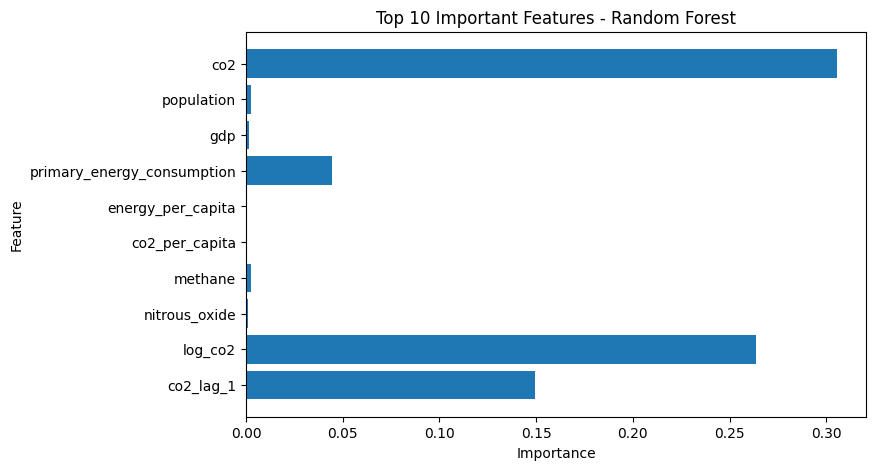

In [64]:
import matplotlib.pyplot as plt


top_rf_features = feature_importance.head(10)


plt.figure(figsize=(8,5))


plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)


plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 10 Important Features - Random Forest"
)


plt.gca().invert_yaxis()

plt.show()

Feature Importance Plot (XGBoost)

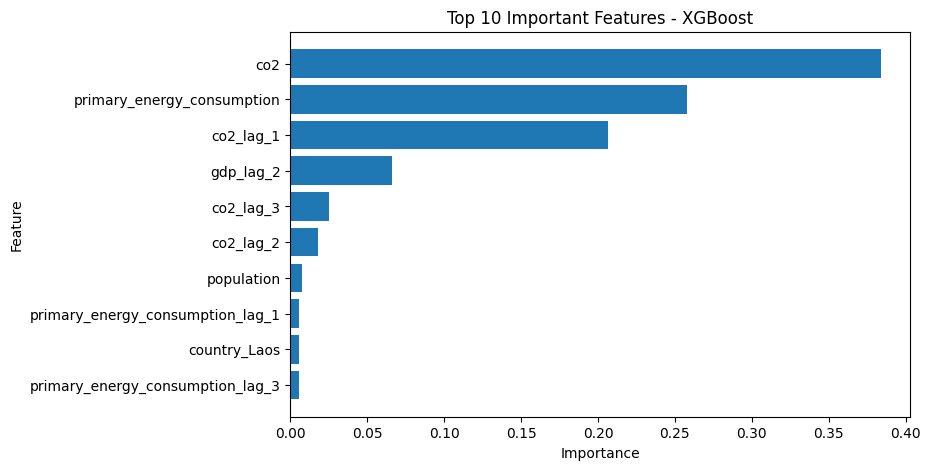

In [65]:
top_xgb_features = xgb_importance.head(10)


plt.figure(figsize=(8,5))


plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)


plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 10 Important Features - XGBoost"
)


plt.gca().invert_yaxis()

plt.show()

**Part 4**

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error


winning_model = best_svm


y_test_pred_log = winning_model.predict(X_test_scaled)


actual_co2_test = np.exp(y_test)
predicted_co2_test = np.exp(y_test_pred_log)


test_mae = mean_absolute_error(actual_co2_test, predicted_co2_test)
test_rmse = np.sqrt(mean_squared_error(actual_co2_test, predicted_co2_test))
test_mape = mean_absolute_percentage_error(actual_co2_test, predicted_co2_test) * 100
test_r2 = r2_score(actual_co2_test, predicted_co2_test)


test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
test_mae_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"Test MAE          : {test_mae:.2f} Mt")
print(f"Test RMSE         : {test_rmse:.2f} Mt")
print(f"Test MAPE         : {test_mape:.2f} %")
print(f"Test R² Score     : {test_r2:.4f}")
print("-" * 45)
print(f"Test Log-RMSE     : {test_rmse_log:.4f}")
print(f"Test Log-MAE      : {test_mae_log:.4f}")
print("=" * 45)

Test MAE          : 58.34 Mt
Test RMSE         : 194.20 Mt
Test MAPE         : 14.76 %
Test R² Score     : 0.9289
---------------------------------------------
Test Log-RMSE     : 0.1823
Test Log-MAE      : 0.1381


----Residual Diagnostics Plots

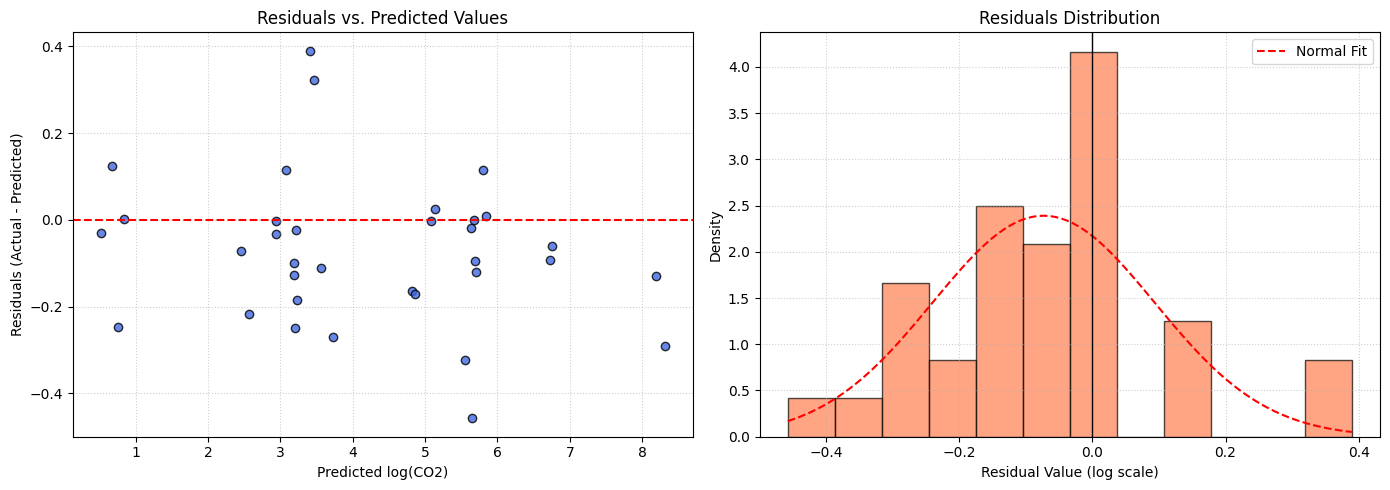

In [68]:
residuals_log = y_test - y_test_pred_log

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.scatter(y_test_pred_log, residuals_log, color='royalblue', alpha=0.8, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted log(CO2)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.hist(residuals_log, bins=12, color='coral', edgecolor='black', alpha=0.7, density=True)

res_mean, res_std = np.mean(residuals_log), np.std(residuals_log)
x_vals = np.linspace(min(residuals_log), max(residuals_log), 100)
p_vals = (1 / (res_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_vals - res_mean) / res_std) ** 2)
plt.plot(x_vals, p_vals, 'r--', label='Normal Fit')

plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.xlabel("Residual Value (log scale)")
plt.ylabel("Density")
plt.title("Residuals Distribution")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Largest-Error Test Cases Table

In [69]:
test_diagnostics = pd.DataFrame({
    'Country': test_df['country'].values,
    'Base Year': test_df['year'].values,
    'Target Forecast Year': test_df['year'].values + 3,
    'Actual CO2 (Mt)': actual_co2_test.values,
    'Predicted CO2 (Mt)': predicted_co2_test,
    'Abs Error (Mt)': np.abs(actual_co2_test.values - predicted_co2_test),
    'Percentage Error (%)': np.abs((actual_co2_test.values - predicted_co2_test) / actual_co2_test.values) * 100
})


top_errors = test_diagnostics.sort_values(by='Abs Error (Mt)', ascending=False).head(10).reset_index(drop=True)

print("Top 10 Largest Error Test Cases:")
top_errors

Top 10 Largest Error Test Cases:


,Country,Base Year,Target Forecast Year,Actual CO2 (Mt),Predicted CO2 (Mt),Abs Error (Mt),Percentage Error (%)
0,India,2020,2023,3062.756001,4092.898393,1030.142392,33.634491
1,India,2021,2024,3193.478001,3632.113005,438.635004,13.735338
2,Pakistan,2021,2024,179.800001,284.152370,104.352369,58.038025
3,Indonesia,2020,2023,762.358001,835.518081,73.160080,9.596552
4,Pakistan,2020,2023,186.861001,258.090932,71.229931,38.119207
5,Indonesia,2021,2024,812.220001,862.612306,50.392305,6.204268
6,Vietnam,2021,2024,370.931001,330.649764,40.281237,10.859496
7,Thailand,2020,2023,264.734001,298.656572,33.922571,12.813832
8,Thailand,2021,2024,267.760001,294.347754,26.587753,9.929696
9,Bangladesh,2021,2024,108.318001,128.540305,20.222304,18.669385


Validation Error Comparison Chart

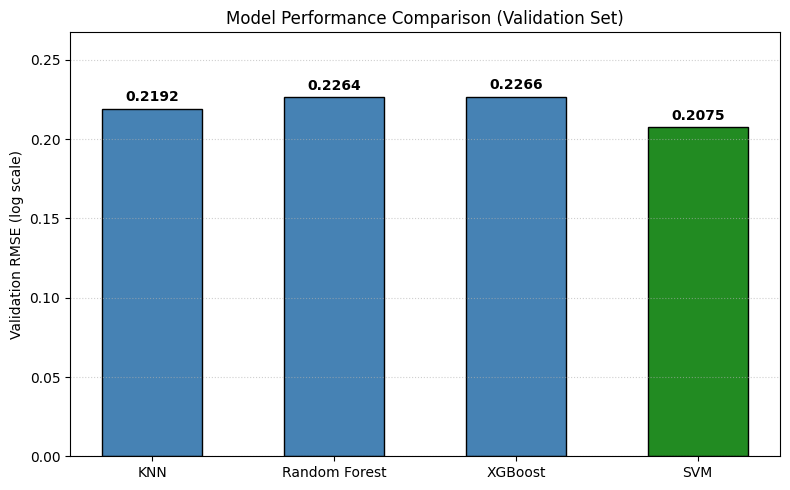

In [70]:

plt.figure(figsize=(8, 5))

models = comparison['Model']
rmse_scores = comparison['Validation RMSE']


colors = ['forestgreen' if m == winner['Model'] else 'steelblue' for m in models]

bars = plt.bar(models, rmse_scores, color=colors, edgecolor='black', width=0.55)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.003,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Validation RMSE (log scale)")
plt.title("Model Performance Comparison (Validation Set)")
plt.ylim(0, max(rmse_scores) * 1.18)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

--Refit Model on Full Dataset

In [71]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


cols_to_drop = ['year', 'iso_code', 'target_3yr_ahead']

X_full = pd.get_dummies(df_model.drop(columns=cols_to_drop), columns=['country'], drop_first=True)
y_full = df_model['target_3yr_ahead']


full_scaler = StandardScaler()
X_full_scaled = full_scaler.fit_transform(X_full)


final_model = SVR(C=1, kernel='linear')
final_model.fit(X_full_scaled, y_full)

print(f"Final model successfully refitted on all {len(X_full)} historical rows!")

Final model successfully refitted on all 493 historical rows!


----Out-of-Sample Forecast (2025-2027) & Plot

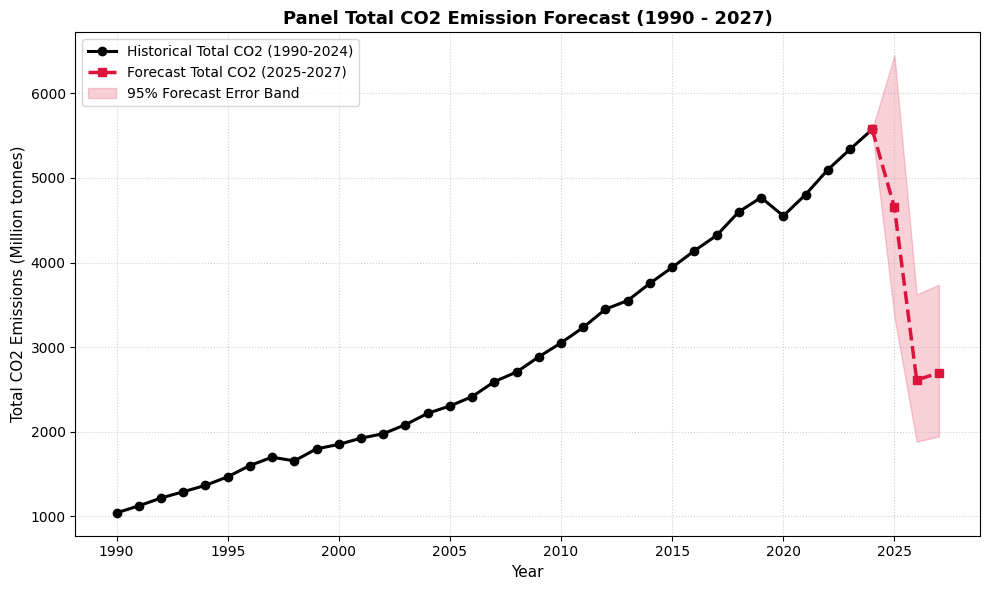

Final Forecast Table (Total Panel CO2):


,Year,Forecast (Mt),Lower 95% (Mt),Upper 95% (Mt)
0,2025,4651.555801,3353.634958,6451.796823
1,2026,2611.342675,1882.701284,3621.982213
2,2027,2695.661488,1943.492669,3738.934019


In [72]:
latest_data = df_engineered[df_engineered['year'] >= 2022].copy()


X_future = pd.get_dummies(latest_data.drop(columns=['year', 'iso_code'], errors='ignore'),
                          columns=['country'], drop_first=True)

for col in X_full.columns:
    if col not in X_future.columns:
        X_future[col] = 0
X_future = X_future[X_full.columns]

X_future_scaled = full_scaler.transform(X_future)


latest_data['forecast_year'] = latest_data['year'] + 3
latest_data['forecast_co2_log'] = final_model.predict(X_future_scaled)
latest_data['forecast_co2'] = np.exp(latest_data['forecast_co2_log'])


hist_panel = df_clean.groupby('year')['co2'].sum().reset_index()
future_panel = latest_data.groupby('forecast_year')['forecast_co2'].sum().reset_index()


residual_std = np.std(residuals_log)
future_panel['lower_bound'] = future_panel['forecast_co2'] * np.exp(-1.96 * residual_std)
future_panel['upper_bound'] = future_panel['forecast_co2'] * np.exp(1.96 * residual_std)


plt.figure(figsize=(10, 6))


plt.plot(hist_panel['year'], hist_panel['co2'], label='Historical Total CO2 (1990-2024)',
         color='black', linewidth=2.2, marker='o')


last_hist_year = hist_panel['year'].iloc[-1]
last_hist_co2 = hist_panel['co2'].iloc[-1]

plot_years = [last_hist_year] + list(future_panel['forecast_year'])
plot_forecast = [last_hist_co2] + list(future_panel['forecast_co2'])
plot_lower = [last_hist_co2] + list(future_panel['lower_bound'])
plot_upper = [last_hist_co2] + list(future_panel['upper_bound'])

plt.plot(plot_years, plot_forecast, label='Forecast Total CO2 (2025-2027)',
         color='crimson', linewidth=2.5, linestyle='--', marker='s')


plt.fill_between(plot_years, plot_lower, plot_upper, color='crimson', alpha=0.2,
                 label='95% Forecast Error Band')

plt.title("Panel Total CO2 Emission Forecast (1990 - 2027)", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=11)
plt.ylabel("Total CO2 Emissions (Million tonnes)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


print("Final Forecast Table (Total Panel CO2):")
display(future_panel[['forecast_year', 'forecast_co2', 'lower_bound', 'upper_bound']].rename(
    columns={'forecast_year': 'Year', 'forecast_co2': 'Forecast (Mt)',
             'lower_bound': 'Lower 95% (Mt)', 'upper_bound': 'Upper 95% (Mt)'}
))